# Multi-Terrain Evaluation Analysis

This notebook loads all CSV evaluation files for a selected approach from an experiment folder, computes metrics per terrain, and computes pooled metrics across all terrains.

Expected filename pattern:

```text
{approach}_{terrain}_{disturbance_condition}.csv
```

Example:

```text
pact_rough_payload.csv
pos_stairs_push.csv
tau_plane_none.csv
```

Set `EXP_FOLDER`, `APPROACH`, and optionally `DISTURBANCE_CONDITION` in the configuration cell below.


In [1]:
import os
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

try:
    import seaborn as sns
except ImportError:
    sns = None


## Configuration

In [2]:
# --- User settings ---
EXP_FOLDER = "exp_data_corl_stronger_boot/"
APPROACH = "go1_pact"

# Set to None to load every disturbance condition for this approach.
# Otherwise use strings like "none", "payload", "push", etc.
DISTURBANCE_CONDITION = None

# Optional output directory for result tables
RESULTS_DIR = Path(EXP_FOLDER) / "analysis_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Default target used for height tracking.
BASE_HEIGHT_TARGET = 0.30

# Optional constants used only for limit violation metrics.
# Expected shapes:
#   JOINT_LIMITS: [2, num_dofs], where row 0 is lower and row 1 is upper
#   JOINT_TORQUE_LIMITS: scalar or [num_dofs]
JOINT_LIMITS = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])
JOINT_TORQUE_LIMITS = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

EPS = 1e-8

EXCLUDE_DIRS = ["analysis_results"]

NUM_WORKERS = 20

## Loading utilities

In [3]:
def string_to_array(array_string):
    """Convert stringified list/array columns from the logger into Python lists."""
    if isinstance(array_string, str):
        try:
            return ast.literal_eval(array_string)
        except (ValueError, SyntaxError):
            return array_string
    return array_string


ARRAY_COLUMNS = [
    "base_cmd",
    "base_pose",
    "base_rpy",
    "dof_pose",
    "base_lin_vel",
    "base_ang_vel",
    "dof_vel",
    "proj_grav",
    "feet_pos",
    "tau_act",
    "grf",
    "q_des",
    "tau_ff",
    "tau_pd",
    "payload",
    "com_shift",
    "rand_push",
    "rand_wrench",
]


def get_csv_converters(columns=ARRAY_COLUMNS):
    return {col: string_to_array for col in columns}


def parse_eval_filename(path, approach):
    """
    Parse filenames of the form:
        {approach}_{terrain}_{disturbance_condition}.csv

    This assumes the terrain token comes immediately after the approach token.
    Everything after the terrain token is treated as the disturbance condition.
    """
    stem = Path(path).stem

    prefix = f"{approach}_"
    if not stem.startswith(prefix):
        return None

    remainder = stem[len(prefix):]
    parts = remainder.split("_")

    if len(parts) < 2:
        return None

    terrain = parts[0]
    disturbance_condition = "_".join(parts[1:])

    return {
        "approach": approach,
        "terrain": terrain,
        "disturbance_condition": disturbance_condition,
        "path": Path(path),
    }


def find_eval_files(exp_folder, approach, disturbance_condition=None):
    exp_folder = Path(exp_folder)

    records = []
    for path in sorted(exp_folder.rglob(f"{approach}_*.csv")):
        info = parse_eval_filename(path, approach)
        if info is None:
            continue

        # Skip blacklisted subdirectories
        if EXCLUDE_DIRS:
            rel_parts = path.relative_to(exp_folder).parts
            if any(part in EXCLUDE_DIRS for part in rel_parts):
                continue

        if disturbance_condition is not None:
            if info["disturbance_condition"] != disturbance_condition:
                continue

        records.append(info)

    return pd.DataFrame(records)


def load_eval_csv(path):
    """Load one evaluation CSV with logger array columns converted."""
    return pd.read_csv(path, converters=get_csv_converters())


def load_eval_dataset(file_table):
    """
    Load all files in file_table and concatenate them into one dataframe.

    Adds:
        approach
        terrain
        disturbance_condition
        source_file
    """
    dfs = []

    for _, row in file_table.iterrows():
        df = load_eval_csv(row["path"])

        df["approach"] = row["approach"]
        df["terrain"] = row["terrain"]
        df["disturbance_condition"] = row["disturbance_condition"]
        df["source_file"] = str(row["path"])

        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)


def _load_one_eval_file(row):
    df = load_eval_csv(row["path"])

    df["approach"] = row["approach"]
    df["terrain"] = row["terrain"]
    df["disturbance_condition"] = row["disturbance_condition"]
    df["source_file"] = str(row["path"])

    return df

def load_eval_dataset_parallel(file_table, max_workers=10):
    rows = [row for _, row in file_table.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        dfs = list(executor.map(_load_one_eval_file, rows))

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)

In [4]:
file_table = find_eval_files(
    EXP_FOLDER,
    APPROACH,
    disturbance_condition=DISTURBANCE_CONDITION,
)

file_table


,approach,terrain,disturbance_condition,path
0,go1_pact,discrete,none,exp_data_corl_stronger_boot/no_disturbance/go1...
1,go1_pact,plane,none,exp_data_corl_stronger_boot/no_disturbance/go1...
2,go1_pact,rough,none,exp_data_corl_stronger_boot/no_disturbance/go1...
3,go1_pact,slope,none,exp_data_corl_stronger_boot/no_disturbance/go1...
4,go1_pact,stairs,none,exp_data_corl_stronger_boot/no_disturbance/go1...
5,go1_pact,wave,none,exp_data_corl_stronger_boot/no_disturbance/go1...
6,go1_pact,discrete,payload,exp_data_corl_stronger_boot/payload_disturbanc...
7,go1_pact,plane,payload,exp_data_corl_stronger_boot/payload_disturbanc...
8,go1_pact,rough,payload,exp_data_corl_stronger_boot/payload_disturbanc...
9,go1_pact,slope,payload,exp_data_corl_stronger_boot/payload_disturbanc...


In [5]:
df_all = load_eval_dataset_parallel(file_table, max_workers=NUM_WORKERS)

print(f"Loaded {len(file_table)} files")
print(f"Loaded {len(df_all):,} rows")
print("Terrains:", sorted(df_all["terrain"].unique()))
print("Disturbance conditions:", sorted(df_all["disturbance_condition"].unique()))

df_all.head()


Loaded 18 files
Loaded 7,200,000 rows
Terrains: ['discrete', 'plane', 'rough', 'slope', 'stairs', 'wave']
Disturbance conditions: ['none', 'payload', 'push']


,Unnamed: 0,base_cmd,base_pose,base_rpy,dof_pose,base_lin_vel,base_ang_vel,dof_vel,proj_grav,feet_pos,...,tau_pd,failure,payload,com_shift,rand_push,rand_wrench,approach,terrain,disturbance_condition,source_file
0,0,"[0.0, -0.0, -0.4132533669471741, -0.8331868052...","[3.770160436630249, 3.5180091857910156, 0.3340...","[-0.009614778682589531, -0.0012164541985839605...","[0.17995421588420868, 0.9399373531341553, -1.5...","[-0.18368412554264069, -0.08629000186920166, -...","[-0.22964772582054138, -0.08048807829618454, -...","[0.5008267760276794, 0.9821995496749878, -2.55...","[-0.001216453849337995, 0.009614622220396996, ...","[[3.8993635177612305, 3.4434356689453125, 0.01...",...,"[-8.155073165893555, -4.04163122177124, 0.2502...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_stronger_boot/no_disturbance/go1...
1,1,"[-0.6775726079940796, 0.06778740882873535, 0.6...","[20.399093627929688, 4.271783351898193, 0.3371...","[0.011904445476830006, 0.004579615313559771, -...","[-0.11716178059577942, 0.7261546850204468, -1....","[0.40669265389442444, -0.464639276266098, -0.1...","[0.772362470626831, 0.5040504336357117, -0.684...","[0.10615946352481842, 0.28012794256210327, 1.4...","[0.004579599481076002, -0.011904038488864899, ...","[[20.606353759765625, 4.1119771003723145, 0.05...",...,"[0.4939366579055786, 2.2475311756134033, 2.935...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_stronger_boot/no_disturbance/go1...
2,2,"[0.18936622142791748, -0.07134497165679932, 1....","[27.827320098876953, 3.664743185043335, 0.3416...","[0.011672567576169968, 0.009924597106873989, 0...","[0.03535177558660507, 0.8280177116394043, -1.6...","[-0.13190552592277527, -0.3769949674606323, 0....","[0.7229440212249756, 0.6945385336875916, 0.265...","[-2.5108540058135986, -1.116799235343933, 3.15...","[0.009924433194100857, -0.01167172659188509, -...","[[28.00954818725586, 3.5523505210876465, 0.044...",...,"[-3.7606396675109863, -0.6667624115943909, 3.5...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_stronger_boot/no_disturbance/go1...
3,3,"[0.0, 0.0, 0.47338423132896423, 0.949077844619...","[27.703174591064453, 4.10695219039917, 0.34368...","[0.011567231267690659, -0.009823228232562542, ...","[0.10412818193435669, 0.5550106167793274, -1.5...","[0.09023206681013107, -0.2892944812774658, 0.1...","[0.5240324139595032, -0.6103683114051819, 0.15...","[-1.6392879486083984, 1.2095177173614502, 5.75...","[-0.009823069907724857, -0.01156641449779272, ...","[[27.959142684936523, 4.015925407409668, 0.038...",...,"[0.7450411319732666, 0.7930558919906616, 3.945...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_stronger_boot/no_disturbance/go1...
4,4,"[-0.8110364675521851, 0.18676280975341797, -1....","[3.526973247528076, 4.242716312408447, 0.33690...","[0.029429517686367035, -0.0022487808018922806,...","[0.11123742163181305, 0.9345298409461975, -1.5...","[-0.4549587368965149, -0.43522554636001587, -0...","[1.8681864738464355, -0.12105381488800049, -0....","[-1.0267471075057983, -4.157420635223389, 4.82...","[-0.0022487789392471313, -0.02942519448697567,...","[[3.6738951206207275, 4.157069206237793, 0.032...",...,"[0.6969879865646362, -8.27519416809082, 6.8135...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_stronger_boot/no_disturbance/go1...


## Metric utilities

In [6]:
def as_array(df, column, valid_mask=None):
    """Convert a dataframe column of list-like entries into a numpy array."""
    if column not in df.columns:
        return None

    series = df[column]
    if valid_mask is not None:
        series = series.loc[valid_mask]

    if len(series) == 0:
        return None

    return np.asarray(series.to_list())


def safe_mean(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanmean(x))


def safe_std(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanstd(x))


def rmse(x):
    x = np.asarray(x)
    return float(np.sqrt(np.nanmean(np.square(x))))


def mae(x):
    x = np.asarray(x)
    return float(np.nanmean(np.abs(x)))


def mean_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanmean(np.linalg.norm(x, axis=axis, ord=1)))


def std_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanstd(np.linalg.norm(x, axis=axis, ord=1)))


def rpy_to_rotmat(rpy):
    """
    rpy: (..., 3) roll, pitch, yaw
    returns: (..., 3, 3) rotation matrix (base -> world)
    """
    roll, pitch, yaw = rpy[..., 0], rpy[..., 1], rpy[..., 2]

    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)

    R = np.stack([
        np.stack([cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr], axis=-1),
        np.stack([sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr], axis=-1),
        np.stack([-sp,   cp*sr,            cp*cr           ], axis=-1)
    ], axis=-2)

    return R


In [7]:
def compute_eval_metrics(
    df,
    approach='pact',
    base_height_target=0.30,
    joint_limits=None,
    joint_torque_limits=None,
    pact_metric_approaches=("pact", "abl"),
    eps=1e-8,
):
    """
    Compute scalar evaluation metrics for one dataframe.

    Failed rows are excluded from continuous metrics but counted in failure statistics.
    """
    metrics = {}

    use_pact_metrics = (
        approach is not None
        and any(k.lower() in approach.lower() for k in pact_metric_approaches)
    )

    n_total = len(df)
    failure = df["failure"].astype(float).to_numpy() if "failure" in df.columns else np.zeros(n_total)
    valid_mask = failure == 0

    metrics["num_rows_total"] = int(n_total)
    metrics["num_rows_valid"] = int(valid_mask.sum())
    metrics["num_failures"] = int(failure.sum())
    metrics["failure_rate"] = float(failure.mean()) if n_total > 0 else np.nan

    if valid_mask.sum() == 0:
        return metrics

    q_actions = as_array(df, "q_des", valid_mask)
    q_obs = as_array(df, "dof_pose", valid_mask)

    vel_cmds = as_array(df, "base_cmd", valid_mask)
    lin_vel = as_array(df, "base_lin_vel", valid_mask)
    ang_vel = as_array(df, "base_ang_vel", valid_mask)

    base_pose = as_array(df, "base_pose", valid_mask)
    proj_grav = as_array(df, "proj_grav", valid_mask)

    q_vel = as_array(df, "dof_vel", valid_mask)
    q_tau = as_array(df, "tau_act", valid_mask)

    grfs = as_array(df, "grf", valid_mask)
    ff_tau = as_array(df, "tau_ff", valid_mask)
    pd_tau = as_array(df, "tau_pd", valid_mask)

    # Joint tracking
    if q_actions is not None and q_obs is not None:
        dof_errors = q_actions - q_obs
        metrics["dof_tracking_rmse"] = rmse(dof_errors)
        metrics["dof_tracking_mae"] = mae(dof_errors)
        metrics["q_action_norm_mean"] = mean_norm(q_actions)
        metrics["q_action_norm_std"] = std_norm(q_actions)

        if joint_limits is not None:
            joint_limits = np.asarray(joint_limits)
            joint_pred_limits_error = -(q_actions - joint_limits[0, :]).clip(max=0.0)
            joint_pred_limits_error += (q_actions - joint_limits[1, :]).clip(min=0.0)
            metrics["joint_limit_violation_mean"] = float(np.mean(joint_pred_limits_error))

    # Command tracking
    if vel_cmds is not None and lin_vel is not None and ang_vel is not None:
        lin_cmd_errors = vel_cmds[:, 0:2] - lin_vel[:, 0:2]
        ang_cmd_errors = vel_cmds[:, 2] - ang_vel[:, 2]
        cmd_errs = np.concatenate((lin_cmd_errors, ang_cmd_errors[:, None]), axis=1)

        metrics["lin_cmd_rmse"] = rmse(lin_cmd_errors)
        metrics["lin_cmd_mae"] = mae(lin_cmd_errors)
        metrics["lin_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(lin_cmd_errors))))

        metrics["ang_cmd_rmse"] = rmse(ang_cmd_errors)
        metrics["ang_cmd_mae"] = mae(ang_cmd_errors)
        metrics["ang_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(ang_cmd_errors))))

        metrics["total_cmd_rmse"] = rmse(cmd_errs)
        metrics["total_cmd_mae"] = mae(cmd_errs)

    # Height / orientation / unwanted velocity
    if base_pose is not None:
        height_errors = base_height_target - base_pose[:, 2]
        metrics["height_rmse"] = rmse(height_errors)
        metrics["height_mae"] = mae(height_errors)

    if proj_grav is not None:
        orientation_norm = np.linalg.norm(proj_grav[:, 0:2], axis=1, ord=1)
        metrics["projected_gravity_rp_norm_mean"] = safe_mean(orientation_norm)
        metrics["projected_gravity_rp_norm_std"] = safe_std(orientation_norm)

    if lin_vel is not None and ang_vel is not None:
        z_vel = lin_vel[:, 2]
        ang_vel_rp_norm = np.linalg.norm(ang_vel[:, 0:2], axis=1, ord=1)
        total_unwanted_vel = np.concatenate((z_vel[:, None], ang_vel[:, 0:2]), axis=1)
        total_unwanted_norm = np.linalg.norm(total_unwanted_vel, axis=1, ord=1)

        metrics["z_vel_rmse"] = rmse(z_vel)
        metrics["z_vel_mae"] = mae(z_vel)
        metrics["ang_vel_rp_norm_mean"] = safe_mean(ang_vel_rp_norm)
        metrics["ang_vel_rp_norm_std"] = safe_std(ang_vel_rp_norm)
        metrics["total_unwanted_vel_norm_mean"] = safe_mean(total_unwanted_norm)
        metrics["total_unwanted_vel_norm_std"] = safe_std(total_unwanted_norm)

    # Torque / force / power
    if q_vel is not None and q_tau is not None:
        joint_power = q_vel * q_tau
        metrics["joint_power_norm_mean"] = mean_norm(joint_power)
        metrics["joint_power_norm_std"] = std_norm(joint_power)

    if grfs is not None:
        # Handle either [N, 4, 3] or flattened [N, 12].
        grf_flat = grfs.reshape(grfs.shape[0], -1)
        metrics["grf_norm_mean"] = mean_norm(grf_flat)
        metrics["grf_norm_std"] = std_norm(grf_flat)

    if ff_tau is not None:
        metrics["ff_tau_norm_mean"] = mean_norm(ff_tau)
        metrics["ff_tau_norm_std"] = std_norm(ff_tau)

    if pd_tau is not None:
        metrics["pd_tau_norm_mean"] = mean_norm(pd_tau)
        metrics["pd_tau_norm_std"] = std_norm(pd_tau)

    if use_pact_metrics and ff_tau is not None and pd_tau is not None:
        total_tau_cmd = ff_tau + pd_tau
        metrics["total_tau_cmd_norm_mean"] = mean_norm(total_tau_cmd)
        metrics["total_tau_cmd_norm_std"] = std_norm(total_tau_cmd)

        ff_norm = np.linalg.norm(ff_tau, axis=1)
        pd_norm = np.linalg.norm(pd_tau, axis=1)
        metrics["ff_tau_ratio_mean"] = safe_mean(ff_norm / (ff_norm + pd_norm + eps))
        metrics["pd_tau_ratio_mean"] = safe_mean(pd_norm / (ff_norm + pd_norm + eps))
        metrics["pd_to_ff_tau_norm_ratio"] = float(np.mean(pd_norm) / (np.mean(ff_norm) + eps))

        if joint_torque_limits is not None:
            joint_torque_limits = np.asarray(joint_torque_limits)
            violation = -(total_tau_cmd - (-joint_torque_limits)).clip(max=0.0)
            violation += (total_tau_cmd - joint_torque_limits).clip(min=0.0)
            metrics["joint_torque_limit_violation_mean"] = float(np.mean(violation))

    # FF/PD power interaction metrics
    if use_pact_metrics and ff_tau is not None and pd_tau is not None and q_vel is not None:
        ff_power = ff_tau * q_vel
        pd_power = pd_tau * q_vel
        total_power = (ff_tau + pd_tau) * q_vel

        dot = np.sum(ff_power * pd_power, axis=1)
        ff_power_norm = np.linalg.norm(ff_power, axis=1)
        pd_power_norm = np.linalg.norm(pd_power, axis=1)

        cosine_sim = dot / ((ff_power_norm * pd_power_norm) + eps)

        metrics["ff_power_norm_mean"] = safe_mean(ff_power_norm)
        metrics["pd_power_norm_mean"] = safe_mean(pd_power_norm)
        metrics["pd_to_ff_power_ratio"] = float(np.mean(pd_power_norm) / (np.mean(ff_power_norm) + eps))
        metrics["power_alignment_mean"] = safe_mean(cosine_sim)
        metrics["power_alignment_std"] = safe_std(cosine_sim)

        neg_dot = np.maximum(-dot, 0.0)
        metrics["fraction_antagonistic_energy"] = float(np.sum(neg_dot) / (np.sum(np.abs(dot)) + eps))

        numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_power)
        denominator = np.abs(ff_power) + np.abs(pd_power)
        metrics["internal_power_cancellation"] = float(np.mean(numerator) / (np.mean(denominator) + eps))

    return metrics


## Compute per-terrain and all-terrain metrics

In [8]:
def summarize_by_terrain(df_all):
    rows = []

    group_cols = ["approach", "terrain", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, terrain, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": terrain,
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


def summarize_all_terrains(df_all):
    rows = []

    group_cols = ["approach", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": "ALL",
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


per_terrain_results = summarize_by_terrain(df_all)
all_terrain_results = summarize_all_terrains(df_all)
combined_results = pd.concat([per_terrain_results, all_terrain_results], ignore_index=True)

combined_results


,approach,terrain,disturbance_condition,num_rows_total,num_rows_valid,num_failures,failure_rate,dof_tracking_rmse,dof_tracking_mae,q_action_norm_mean,...,pd_tau_ratio_mean,pd_to_ff_tau_norm_ratio,joint_torque_limit_violation_mean,ff_power_norm_mean,pd_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,power_alignment_std,fraction_antagonistic_energy,internal_power_cancellation
0,go1_pact,discrete,none,400000,399996,4,0.000010,0.127667,0.098990,8.897590,...,0.487351,0.970051,0.002064,22.146276,26.736505,1.207269,0.801134,0.196983,0.002700,0.039591
1,go1_pact,discrete,payload,400000,399935,65,0.000162,0.161112,0.117871,9.088923,...,0.513423,1.093310,0.028440,26.749552,35.568411,1.329682,0.807200,0.199922,0.001696,0.040582
2,go1_pact,discrete,push,400000,399947,53,0.000132,0.154508,0.110813,8.968698,...,0.511129,1.097086,0.033967,30.777580,42.560985,1.382857,0.797579,0.204671,0.002859,0.042300
3,go1_pact,plane,none,400000,400000,0,0.000000,0.116685,0.093110,8.807607,...,0.474643,0.912542,0.000432,19.437471,21.596595,1.111081,0.816449,0.177916,0.000917,0.035677
4,go1_pact,plane,payload,400000,399963,37,0.000092,0.152476,0.113938,9.027780,...,0.503483,1.044785,0.016536,23.964040,29.416934,1.227545,0.820448,0.187828,0.001491,0.037459
5,go1_pact,plane,push,400000,399987,13,0.000032,0.141295,0.105061,8.877085,...,0.499481,1.035928,0.020595,27.039651,33.428363,1.236272,0.803927,0.193855,0.001766,0.040684
6,go1_pact,rough,none,400000,400000,0,0.000000,0.127820,0.100057,8.893661,...,0.492071,0.984838,0.000330,22.494178,26.658363,1.185123,0.796704,0.198885,0.001978,0.040232
7,go1_pact,rough,payload,400000,399941,59,0.000148,0.158138,0.117384,9.067444,...,0.513378,1.089886,0.020279,26.748639,34.360886,1.284584,0.804629,0.202713,0.002161,0.041098
8,go1_pact,rough,push,400000,399958,42,0.000105,0.158137,0.114291,8.987645,...,0.515104,1.112825,0.031672,32.496616,43.752193,1.346362,0.790711,0.210874,0.002323,0.043116
9,go1_pact,slope,none,400000,399999,1,0.000003,0.126568,0.098199,9.037767,...,0.487915,0.968887,0.000437,21.934245,26.236911,1.196162,0.794434,0.205886,0.003427,0.041573


In [9]:
# Save result tables
per_terrain_path = RESULTS_DIR / f"{APPROACH}_per_terrain_results.csv"
all_terrain_path = RESULTS_DIR / f"{APPROACH}_all_terrain_results.csv"
combined_path = RESULTS_DIR / f"{APPROACH}_combined_results.csv"

per_terrain_results.to_csv(per_terrain_path, index=False)
all_terrain_results.to_csv(all_terrain_path, index=False)
combined_results.to_csv(combined_path, index=False)

print("Saved:")
print(per_terrain_path)
print(all_terrain_path)
print(combined_path)


Saved:
exp_data_corl_stronger_boot/analysis_results/go1_pact_per_terrain_results.csv
exp_data_corl_stronger_boot/analysis_results/go1_pact_all_terrain_results.csv
exp_data_corl_stronger_boot/analysis_results/go1_pact_combined_results.csv


## Compact result views

In [10]:
# Choose the metrics you care about most for a compact table.
summary_cols = [
    "approach",
    "terrain",
    "disturbance_condition",
    "num_failures",
    "height_mae",
    "lin_cmd_mae",
    "ang_cmd_mae",
    "projected_gravity_rp_norm_mean",
    "z_vel_mae",
    "ang_vel_rp_norm_mean",
    "dof_tracking_mae",
    "joint_power_norm_mean",
    "pd_to_ff_power_ratio",
    "power_alignment_mean",
    "fraction_antagonistic_energy",
    "internal_power_cancellation",
]

available_summary_cols = [c for c in summary_cols if c in combined_results.columns]

compact_results = combined_results[available_summary_cols].copy()
compact_results


,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation
0,go1_pact,discrete,none,4,0.041253,0.110489,0.143568,0.083508,0.058616,0.613980,0.098990,46.484732,1.207269,0.801134,0.002700,0.039591
1,go1_pact,discrete,payload,65,0.036875,0.141151,0.179535,0.126917,0.078526,0.666577,0.117871,55.076083,1.329682,0.807200,0.001696,0.040582
2,go1_pact,discrete,push,53,0.042070,0.276944,0.226143,0.109424,0.105678,0.911970,0.110813,75.488246,1.382857,0.797579,0.002859,0.042300
3,go1_pact,plane,none,0,0.035957,0.088018,0.112549,0.058573,0.036647,0.480262,0.093110,37.394820,1.111081,0.816449,0.000917,0.035677
4,go1_pact,plane,payload,37,0.026892,0.118896,0.146442,0.110239,0.060878,0.549517,0.113938,44.270760,1.227545,0.820448,0.001491,0.037459
5,go1_pact,plane,push,13,0.036297,0.263240,0.187572,0.084758,0.081155,0.791390,0.105061,61.721702,1.236272,0.803927,0.001766,0.040684
6,go1_pact,rough,none,0,0.034254,0.115735,0.151819,0.084545,0.073071,0.645883,0.100057,47.885151,1.185123,0.796704,0.001978,0.040232
7,go1_pact,rough,payload,59,0.028291,0.149052,0.185042,0.123550,0.091408,0.701164,0.117384,55.031862,1.284584,0.804629,0.002161,0.041098
8,go1_pact,rough,push,42,0.034466,0.287420,0.240373,0.115084,0.124156,0.980165,0.114291,80.061674,1.346362,0.790711,0.002323,0.043116
9,go1_pact,slope,none,1,0.380863,0.112170,0.133923,0.120814,0.059009,0.582499,0.098199,44.393785,1.196162,0.794434,0.003427,0.041573


In [11]:
compact_results.round(3)

,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation
0,go1_pact,discrete,none,4,0.041,0.110,0.144,0.084,0.059,0.614,0.099,46.485,1.207,0.801,0.003,0.040
1,go1_pact,discrete,payload,65,0.037,0.141,0.180,0.127,0.079,0.667,0.118,55.076,1.330,0.807,0.002,0.041
2,go1_pact,discrete,push,53,0.042,0.277,0.226,0.109,0.106,0.912,0.111,75.488,1.383,0.798,0.003,0.042
3,go1_pact,plane,none,0,0.036,0.088,0.113,0.059,0.037,0.480,0.093,37.395,1.111,0.816,0.001,0.036
4,go1_pact,plane,payload,37,0.027,0.119,0.146,0.110,0.061,0.550,0.114,44.271,1.228,0.820,0.001,0.037
5,go1_pact,plane,push,13,0.036,0.263,0.188,0.085,0.081,0.791,0.105,61.722,1.236,0.804,0.002,0.041
6,go1_pact,rough,none,0,0.034,0.116,0.152,0.085,0.073,0.646,0.100,47.885,1.185,0.797,0.002,0.040
7,go1_pact,rough,payload,59,0.028,0.149,0.185,0.124,0.091,0.701,0.117,55.032,1.285,0.805,0.002,0.041
8,go1_pact,rough,push,42,0.034,0.287,0.240,0.115,0.124,0.980,0.114,80.062,1.346,0.791,0.002,0.043
9,go1_pact,slope,none,1,0.381,0.112,0.134,0.121,0.059,0.582,0.098,44.394,1.196,0.794,0.003,0.042


## Plot selected metrics by terrain

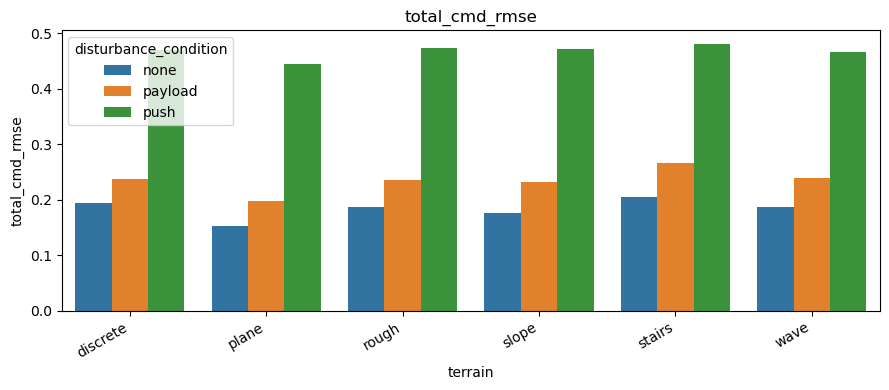

In [12]:
def plot_metric_by_terrain(results, metric, include_all=False):
    plot_df = results.copy()
    if not include_all:
        plot_df = plot_df[plot_df["terrain"] != "ALL"]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(9, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="disturbance_condition")
    else:
        for condition, group in plot_df.groupby("disturbance_condition"):
            plt.bar(group["terrain"], group[metric], label=condition)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


plot_metric_by_terrain(combined_results, "total_cmd_rmse")


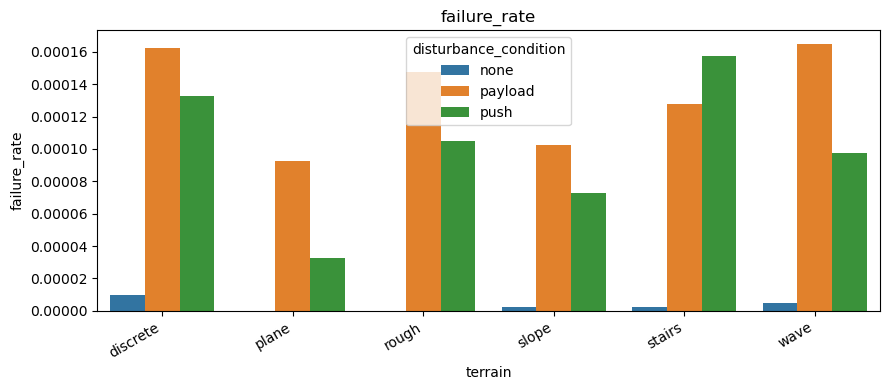

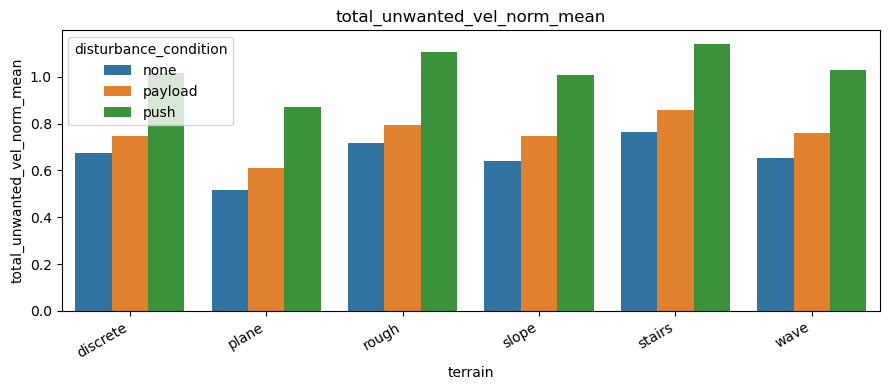

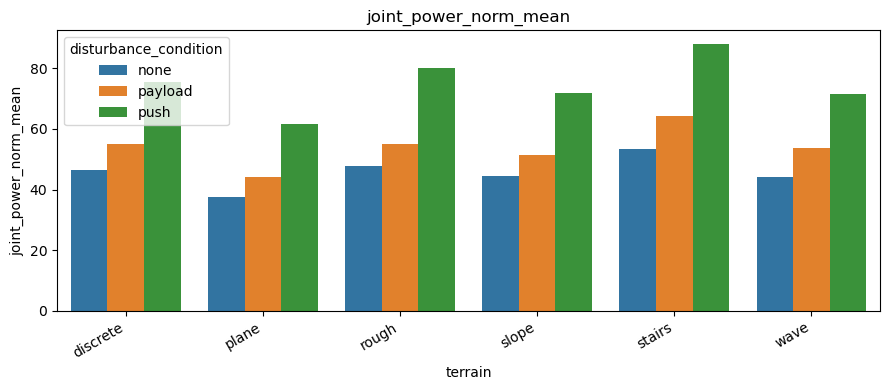

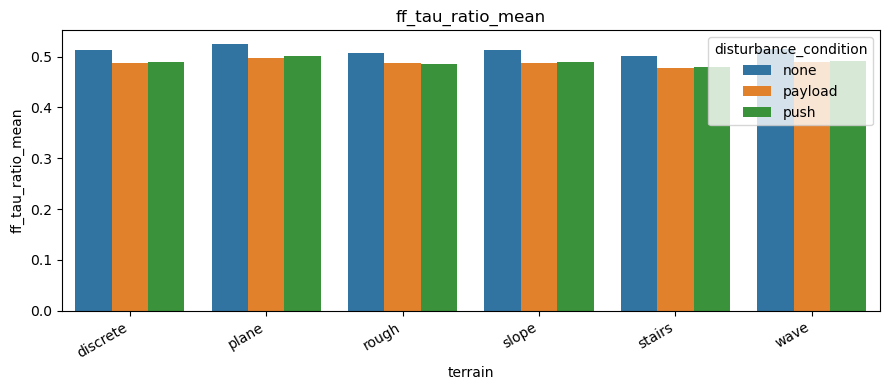

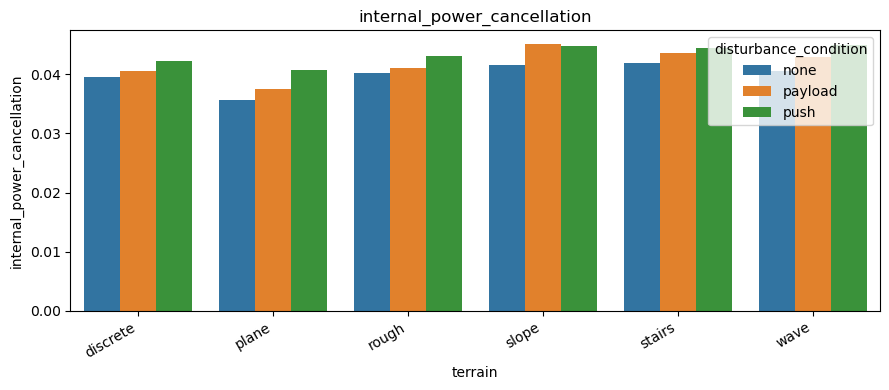

In [13]:
# Example additional plots
for metric in [
    "failure_rate",
    "total_unwanted_vel_norm_mean",
    "joint_power_norm_mean",
    "ff_tau_ratio_mean",
    "internal_power_cancellation",
]:
    if metric in combined_results.columns:
        plot_metric_by_terrain(combined_results, metric)


## Optional: compare multiple approaches

If you want to compare several approaches under the same experiment folder, set `APPROACHES` below and run the cell. It reuses the same functions above.


In [14]:
APPROACHES = ["pact"]  # e.g., ["pact", "pos", "tau"]

all_approach_dfs = []
for approach in APPROACHES:
    ft = find_eval_files(
        EXP_FOLDER,
        approach,
        disturbance_condition=DISTURBANCE_CONDITION,
    )
    if len(ft) == 0:
        print(f"No files found for approach: {approach}")
        continue

    all_approach_dfs.append(load_eval_dataset(ft))

if all_approach_dfs:
    df_multi = pd.concat(all_approach_dfs, ignore_index=True)

    multi_per_terrain = summarize_by_terrain(df_multi)
    multi_all_terrain = summarize_all_terrains(df_multi)
    multi_results = pd.concat([multi_per_terrain, multi_all_terrain], ignore_index=True)

    display(multi_results[[c for c in available_summary_cols if c in multi_results.columns]].round(4))
else:
    print("No approach files loaded.")


No files found for approach: pact
No approach files loaded.


In [15]:
def plot_metric_by_approach_and_terrain(results, metric, terrain_filter=None):
    plot_df = results.copy()

    if terrain_filter is not None:
        plot_df = plot_df[plot_df["terrain"].isin(terrain_filter)]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(10, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="approach")
    else:
        for approach, group in plot_df.groupby("approach"):
            plt.bar(group["terrain"], group[metric], label=approach)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


if "multi_results" in globals():
    plot_metric_by_approach_and_terrain(multi_results, "total_cmd_rmse")
